In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import optuna

from sm import NeuralNet
from tune_sm import find_control_voltages_1D

print(optuna.__version__)
optuna.logging.set_verbosity(optuna.logging.WARNING)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

in_features = 7
out_features = 1
hidden_dim = 90
num_layers = 8

model = NeuralNet(in_features, out_features, hidden_dim, num_layers)
state_dict = torch.load("/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_vMB_MCSteps=1e7_num_batches=200.pth", weights_only=False, map_location=device)
print(state_dict.keys())
model.load_state_dict(state_dict=state_dict["model_state_dict"])
model.eval()

4.4.0
cpu
4.4.0
cpu
dict_keys(['model_state_dict', 'args', 'train_losses', 'val_losses'])


NeuralNet(
  (model): Sequential(
    (0): Linear(in_features=7, out_features=90, bias=True)
    (1): BatchNorm1d(90, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=90, out_features=90, bias=True)
    (4): BatchNorm1d(90, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=90, out_features=90, bias=True)
    (7): BatchNorm1d(90, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=90, out_features=90, bias=True)
    (10): BatchNorm1d(90, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=90, out_features=90, bias=True)
    (13): BatchNorm1d(90, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=90, out_features=90, bias=True)
    (16): BatchNorm1d(90, eps=1e-05, momentum=0.1, affine=True, track_runnin

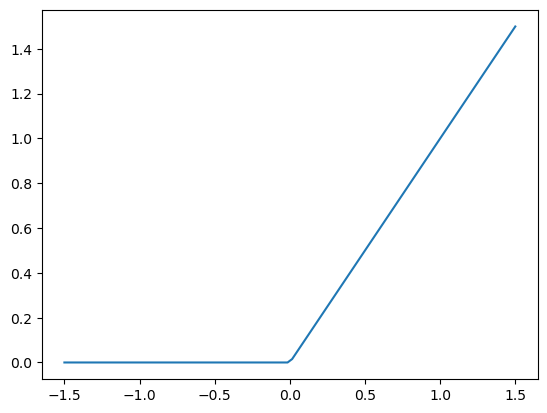

In [111]:
def target_function(t: torch.Tensor):
    N = t.shape[0]
    m = nn.ReLU()
    return m(t)#torch.sigmoid(7*t) - torch.cos(3*t)

target = target_function(torch.linspace(min, max, N)).unsqueeze(1)
plt.plot(np.linspace(min, max, N), target)

In [80]:
N = 100
min = -1.5
max = 1.5

num_studies = 10
best_vals = []

study = find_control_voltages_1D(model=model, target=target, N=N, min_voltage=min, max_voltage=max, input_idx=0)

print("Best value:", study.best_value)
print("Best params:", study.best_params)    

0] Finished with score:  0.431377
100] Finished with score:  0.471024
200] Finished with score:  0.660438
300] Finished with score:  0.739659
400] Finished with score:  0.293604
500] Finished with score:  0.380609
600] Finished with score:  1.312897
700] Finished with score:  0.594077
800] Finished with score:  0.391086
900] Finished with score:  0.452278
1000] Finished with score:  0.096781
1100] Finished with score:  0.041887
1200] Finished with score:  0.160946
1300] Finished with score:  0.015506
1400] Finished with score:  0.061026
1500] Finished with score:  0.014443
1600] Finished with score:  0.027228
1700] Finished with score:  0.037966
1800] Finished with score:  1.102557
1900] Finished with score:  0.639067
Best value: 0.010200503282248974
Best params: {'x_0': -1.4069160476974905, 'x_1': -1.450338915907334, 'x_2': -1.4215249940323482, 'x_3': -0.7840634646105147, 'x_4': 1.019759726709028, 'x_5': -0.9242694280575453}


[-1.4069160476974905, -1.450338915907334, -1.4215249940323482, -0.7840634646105147, 1.019759726709028, -0.9242694280575453]


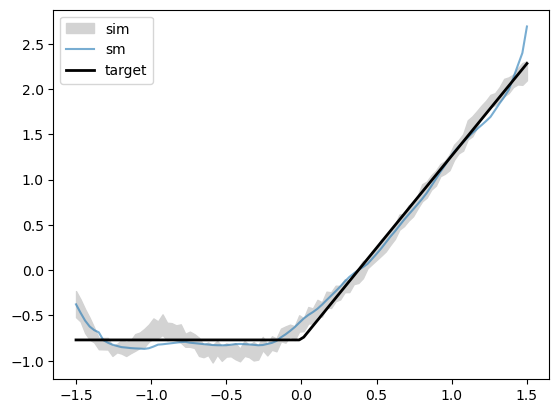

In [124]:
best_vals = []

for v in study.best_params.items():
    best_vals.append(v[1])
print(best_vals)

x = np.linspace(min, max, 100)

v = torch.linspace(min, max, N).unsqueeze(-1)
c_volts = torch.tensor(best_vals, dtype=torch.float32).expand(N, -1)

v_tensor = torch.cat([v, c_volts], dim=1)
y = model(v_tensor).cpu().detach()
y_norm = (y - y.mean()) / y.std()

target_norm = (target - target.mean()) / target.std()

sim_curves = []
for i in range(20):
    data = np.load(f"/home/hd/hd_hd/hd_gy283/kmc_project/data/relu/sim_vMB_best_params_{i}.npz")
    c_norm = (data["current"] - data["current"].mean()) / data["current"].std()
    #plt.plot(x, c_norm, alpha=.6)
    sim_curves.append(c_norm)

sim_curve_mean = np.array(sim_curves).mean(axis=0)
sim_curve_std = np.array(sim_curves).std(ddof=1, axis=0)
plt.fill_between(x, sim_curve_mean+sim_curve_std, sim_curve_mean-sim_curve_std, alpha=1, color="lightgrey", label="sim")
plt.plot(x, y_norm, label="sm", alpha=.6)
plt.plot(x, target_norm, label="target", color="k", lw=2, zorder=3)
plt.legend()